### Full finished code

This is for basic layernorm

In [ ]:
import time
import json
import os

import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.profiler import profile, record_function, ProfilerActivity

In [ ]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-03-17 17:07:52--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.1’

input.txt.1         100%[===================>]   1.06M  --.-KB/s    in 0.03s   

2026-03-17 17:07:52 (36.1 MB/s) - ‘input.txt.1’ saved [1115394/1115394]



In [ ]:
# hyperparameters
batch_size = 16 # how many independent sequences will we process in parallel?
block_size = 32 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 100
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 64
n_head = 4
n_layer = 4
dropout = 0.0
# ------------

torch.manual_seed(1337)

In [ ]:
# wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

In [ ]:
# Train and test splits
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

In [ ]:
# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [ ]:
class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

In [ ]:
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

In [ ]:
class CustomLayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
        self.bias = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        orig_dtype = x.dtype
        x_float = x.float()

        mean = x_float.mean(dim=-1, keepdim=True)
        var = x_float.var(dim=-1, keepdim=True, unbiased=False)

        x_norm = (x_float - mean) * torch.rsqrt(var + self.eps)
        x_norm = x_norm.to(orig_dtype)

        w = self.weight.view(*([1]*(x.dim()-1)), -1)
        b = self.bias.view(*([1]*(x.dim()-1)), -1)

        return x_norm * w + b

In [ ]:
class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = CustomLayerNorm(n_embd)
        self.ln2 = CustomLayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


In [ ]:
# gpt model
class GPTModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = CustomLayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx


In [ ]:
model = GPTModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

0.209729 M parameters


In [ ]:
loss_levels       = []
time_get_batch    = []
time_forward      = []
time_backward     = []
time_optimizer    = []

In [ ]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

activities = [ProfilerActivity.CPU]
if torch.cuda.is_available():
    activities.append(ProfilerActivity.CUDA)

with profile(
    activities=activities,
    record_shapes=True,
    profile_memory=True,
    schedule=torch.profiler.schedule(wait=1, warmup=1, active=3),
    on_trace_ready=torch.profiler.tensorboard_trace_handler('./prof_logs'),
) as prof:

    for iter in range(max_iters):

        if iter % eval_interval == 0 or iter == max_iters - 1:
            losses = estimate_loss()
            print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

        t0 = time.time()
        xb, yb = get_batch('train')
        time_get_batch.append(time.time() - t0)

        t0 = time.time()
        logits, loss = model(xb, yb)
        time_forward.append(time.time() - t0)

        loss_levels.append(loss.item())

        t0 = time.time()
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        time_backward.append(time.time() - t0)

        t0 = time.time()
        optimizer.step()
        time_optimizer.append(time.time() - t0)

        prof.step()

    key_avgs = prof.key_averages()




step 0: train loss 4.4116, val loss 4.4022


/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


step 100: train loss 2.6568, val loss 2.6670
step 200: train loss 2.5090, val loss 2.5058
step 300: train loss 2.4195, val loss 2.4335
step 400: train loss 2.3499, val loss 2.3562
step 500: train loss 2.2965, val loss 2.3128
step 600: train loss 2.2409, val loss 2.2501
step 700: train loss 2.2054, val loss 2.2190
step 800: train loss 2.1638, val loss 2.1867
step 900: train loss 2.1241, val loss 2.1500
step 1000: train loss 2.1030, val loss 2.1300
step 1100: train loss 2.0691, val loss 2.1185
step 1200: train loss 2.0383, val loss 2.0803
step 1300: train loss 2.0243, val loss 2.0635
step 1400: train loss 1.9923, val loss 2.0364
step 1500: train loss 1.9699, val loss 2.0295
step 1600: train loss 1.9642, val loss 2.0488
step 1700: train loss 1.9402, val loss 2.0128
step 1800: train loss 1.9075, val loss 1.9948
step 1900: train loss 1.9073, val loss 1.9865
step 2000: train loss 1.8850, val loss 1.9963
step 2100: train loss 1.8706, val loss 1.9754
step 2200: train loss 1.8616, val loss 1.96

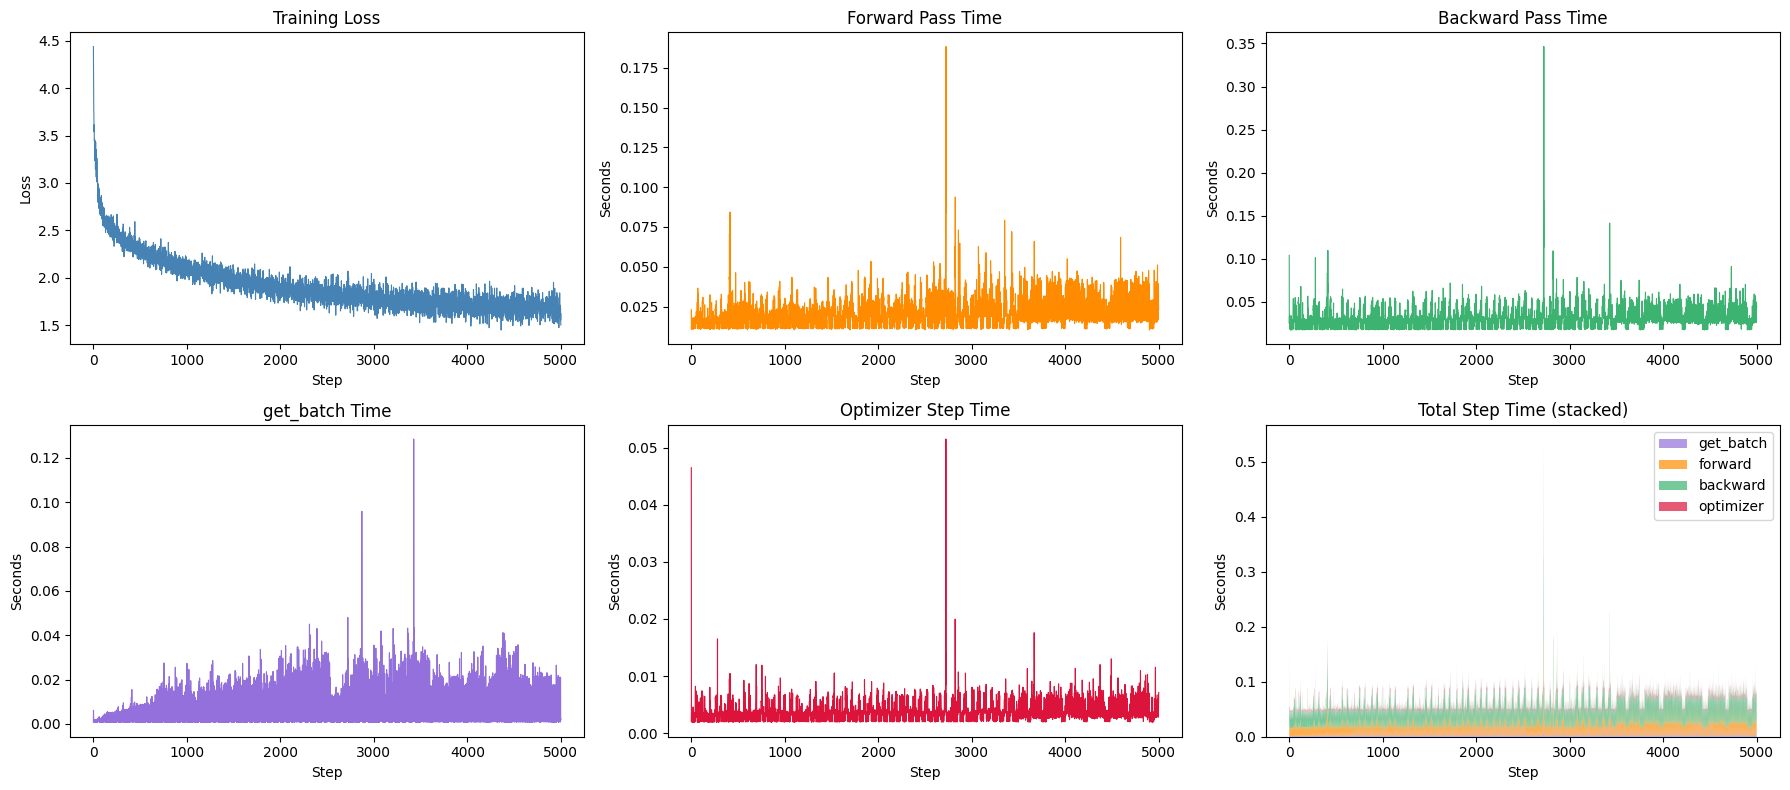

In [ ]:
import matplotlib.pyplot as plt

steps = list(range(len(loss_levels)))

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

axes[0,0].plot(steps, loss_levels, color='steelblue', linewidth=0.8)
axes[0,0].set_title('Training Loss')
axes[0,0].set_xlabel('Step')
axes[0,0].set_ylabel('Loss')

axes[0,1].plot(steps, time_forward, color='darkorange', linewidth=0.8)
axes[0,1].set_title('Forward Pass Time')
axes[0,1].set_xlabel('Step')
axes[0,1].set_ylabel('Seconds')

axes[0,2].plot(steps, time_backward, color='mediumseagreen', linewidth=0.8)
axes[0,2].set_title('Backward Pass Time')
axes[0,2].set_xlabel('Step')
axes[0,2].set_ylabel('Seconds')

axes[1,0].plot(steps, time_get_batch, color='mediumpurple', linewidth=0.8)
axes[1,0].set_title('get_batch Time')
axes[1,0].set_xlabel('Step')
axes[1,0].set_ylabel('Seconds')

axes[1,1].plot(steps, time_optimizer, color='crimson', linewidth=0.8)
axes[1,1].set_title('Optimizer Step Time')
axes[1,1].set_xlabel('Step')
axes[1,1].set_ylabel('Seconds')

# stacked area of all timings together
axes[1,2].stackplot(steps,
    time_get_batch, time_forward, time_backward, time_optimizer,
    labels=['get_batch', 'forward', 'backward', 'optimizer'],
    colors=['mediumpurple', 'darkorange', 'mediumseagreen', 'crimson'],
    alpha=0.7)
axes[1,2].set_title('Total Step Time (stacked)')
axes[1,2].set_xlabel('Step')
axes[1,2].set_ylabel('Seconds')
axes[1,2].legend(loc='upper right')

plt.tight_layout()
plt.savefig('training_profile.png', dpi=150)
plt.show()

In [ ]:
sum(time_forward)/len(time_forward)

0.0210990846157074

In [ ]:
sum(time_backward)/len(time_backward)

0.032822514724731446

In [ ]:
save_path = './training_logs.json'

logs = {
    'loss_levels'    : loss_levels,
    'time_get_batch' : time_get_batch,
    'time_forward'   : time_forward,
    'time_backward'  : time_backward,
    'time_optimizer' : time_optimizer,
}

with open(save_path, 'w') as f:
    json.dump(logs, f)

print(f"saved to {save_path}")

saved to ./training_logs.json


In [ ]:
save_dir = './checkpoints'
os.makedirs(save_dir, exist_ok=True)

# save model
torch.save({
    'model_state_dict'     : model.state_dict(),
    'optimizer_state_dict' : optimizer.state_dict(),
    'loss_levels'          : loss_levels,
    'time_get_batch'       : time_get_batch,
    'time_forward'         : time_forward,
    'time_backward'        : time_backward,
    'time_optimizer'       : time_optimizer,
}, './checkpoints/gpt_checkpoint.pt')

print("saved to ./checkpoints/gpt_checkpoint.pt")

saved to ./checkpoints/gpt_checkpoint.pt


In [ ]:
# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))


And they bride will to lovest madie;
Thou but take Our my called
My art that us his vetward that ane away, my fears' to zorm heavens, to that I he milend;
Whate misters, I in latient, to by Sannent lings on that wiells not
That thus wonchiry: there's speak you love.
In Bodiet, and whom.

CORIOLANUS:
Go Windo what evily we arm dour will now;
But poor of his butt kingnters, If so;
Angint my monter all of while Prive my of.

HENRY BOLINGS:
You ardsabed is great hung couldear tear rents
Inforn maNey, no to too marrity frient, my master and seemenn;
There with reason; staugh he wilt weep on,
Thou confessy that that lome
Is as detlemed thesse everew in movet,--most?

Let Pesink her; How
Os in deasure fetch as nother's move
Tunnies, is duke in, more are wanter.

HORTHISTER:
Where these voiluman, my dossirels not a vy,
These I subself. I know.

ROMEO:
Let this maid I dook, is onter not the summan.

QUEEN ELIZABELLA:
Has must permless keep you his
For father watch the
ought in fort;
you well h